# Halo Mass Function Comparison

Here we intend to compare our Halo Mass Function (HMF) to Matteo Costanzi's.

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd

# First - we load in Matteo's HMF
matteos_hmf = np.loadtxt('mf_z0_z03.dat')
# Second column is log10(M / h), convert to M / h
matteos_hmf = pd.DataFrame({'z': matteos_hmf[:, 0],
                            'm_h': 10** matteos_hmf[:, 1],
                            'hmf': matteos_hmf[:, 2]})
matteos_hmf['m_h'].unique().shape

(100,)

In [6]:
# Load in the direct output from a CosmoSIS run
cosmosis_output_dir = '../cosmosis_test_output/'
hmf_dir = '../cosmosis_test_output/mass_function/'

# Read in HMF
our_z = np.loadtxt(cosmosis_output_dir + 'mass_function/z.txt')
our_m_h = np.loadtxt(cosmosis_output_dir + 'mass_function/m_h.txt')
our_hmf = np.loadtxt(cosmosis_output_dir + 'mass_function/dndlnmh.txt')

# Read in relevant parameters
h0, omega_m, omega_nu = None, None, None
with open(cosmosis_output_dir + 'cosmological_parameters/values.txt') as f:
    for line in f.readlines():
        name, eq, val = line.split()
        assert eq == '='
        val = float(val)
        if name == 'h0':
            h0 = val
        if name == 'omega_m':
            omega_m = val
        if name == 'omega_nu':
            omega_nu = val
omega_cdm = omega_m - omega_nu
    
if None in (h0, omega_m, omega_nu):
    assert False, "Cosmosis output is missing a needed parameter"
            
# Adjust our mass function to relative units
# TODO: Is this right? Do we need to adjust by h0 or anything?
our_m_h *= omega_cdm

arr = []
for i, z in enumerate(our_z):
    for j, m in enumerate(our_m_h):
        # Our HMF is `dn/d(lnM_h)`, convert to
        # `dn/dM_h` for comparison
        arr.append((z, m, our_hmf[i, j] / m))

arr = np.array(arr)
our_hmf = pd.DataFrame({'z': arr[:, 0], 'm_h': arr[:, 1], 'hmf': arr[:, 2]})
mask = (our_hmf['m_h'] >= np.min(matteos_hmf['m_h'])) & (our_hmf['m_h'] <= np.max(matteos_hmf['m_h']))
our_hmf = our_hmf.where(mask).dropna()
our_hmf

OSError: ../cosmosis_test_output/mass_function/z.txt not found.

# Comparison

We have loaded in Matteo's Halo Mass Function, and our own from CosmoSIS output. Now let's make some figures to compare them.

Text(0,0.5,"$\\frac{Ours - Matteo's}{Matteo's}$")

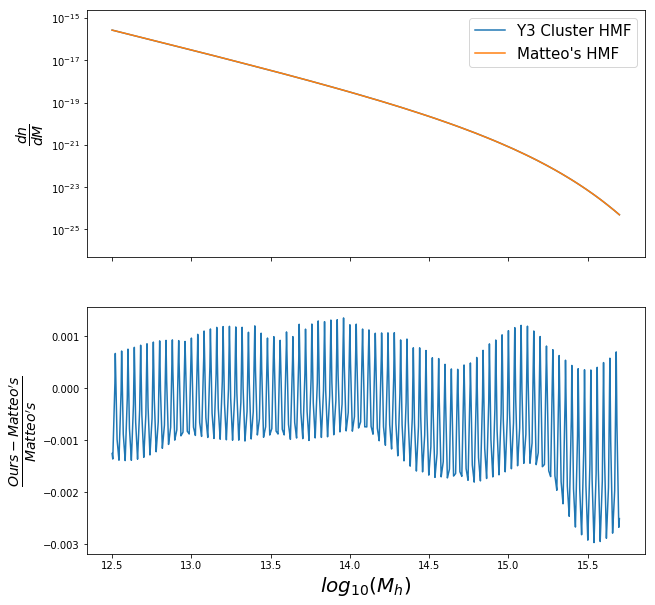

In [3]:
ours = our_hmf.where(our_hmf['z'] == 0).dropna()
matteos = matteos_hmf.where(matteos_hmf['z'] == 0).dropna()

# Our HMF and Matteo's are calculated over different grids - we must
# interpolate to compare them on the same points
def interp_ours(x):
    s = 4.50732047e-2
    q = 1.01958078
    raw = np.interp(x, ours['m_h'], np.log(ours['hmf']))
    return np.exp(raw) * (s * (np.log(x) * math.log(math.e, 10) - 13.8124426028) + q)

def interp_matteos(x):
    return np.exp(np.interp(x, matteos['m_h'], np.log(matteos['hmf'])))

xlog = np.linspace(12.5, 15.7, 100000)
ours_interped = interp_ours(10**xlog)
matteos_interped = interp_matteos(10**xlog)

# Plot absolute HMF together
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 10), sharex=True)
ax1.plot(xlog, ours_interped, label='Y3 Cluster HMF')
ax1.plot(xlog, matteos_interped, label='Matteo\'s HMF')
ax1.set_ylabel(r'$\frac{dn}{dM}$', fontsize=20)
ax1.set_yscale('log')
ax1.set_ylim((ours['hmf'].min(), ours['hmf'].max()))
ax1.legend(fontsize=15)

# Plot residual - relative difference
ax2.plot(xlog, (ours_interped - matteos_interped) / matteos_interped, label='Mass Function Residual')
ax2.set_xlabel(r'$log_{10}(M_h)$', fontsize=20)
ax2.set_ylabel(r"$\frac{Ours - Matteo's}{Matteo's}$", fontsize=20)